Hybrid Search RAG architecture implemented using langChain and Hugginface. PinceconeDB stores embeddings in cloud.

In [ ]:
!pip install --upgrade --quiet pinecone-client pinecone-text pinecone-notebooks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 2.2 MB/s eta 0:00:00


In [ ]:
api_key="pcsk_2TbW6L_SkzqoEqzhr3DbuoMdL6qMrTvsuxbWzB2HFk5RK5moJynRmg9gpU1pecJfiTet1n"

In [ ]:
!pip install langchain_community
from langchain_community.retrievers import PineconeHybridSearchRetriever

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is inc

In [ ]:
import os
!pip install pinecone

from pinecone import Pinecone,ServerlessSpec
index_name="hybrid-search-langchain-pinecone"
##initialize pinecone client
pc=Pinecone(api_key=api_key)
if index_name not in pc.list_indexes().names():
  pc.create_index(name=index_name,dimension=384,metric="dotproduct",spec=ServerlessSpec(cloud="aws",region="us-east-1"))##dimensions for dense values and metric for sparse value support


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 12.6 MB/s eta 0:00:00


In [ ]:
index=pc.Index(index_name)
index

Index(host='https://hybrid-search-langchain-pinecone-fnlo9co.svc.aped-4627-b74a.pinecone.io')

In [ ]:
## using vector embeddings and sparse matrix
import os
from dotenv import load_dotenv
load_dotenv()

!pip install langchain_huggingface
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
embeddings

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [ ]:
from pinecone_text.sparse import BM25Encoder
bm25_encoder=BM25Encoder.default()#responsibler for sparse matrix conversion
bm25_encoder

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
sentences=["In 2023 i visited paris","In 2022 I visited new york","in 2021 i visited london"]
##tfidf values on these sentences
bm25_encoder.fit(sentences)
bm25_encoder.dump("bm25_encoder.json")

  0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
retriever=PineconeHybridSearchRetriever(
    embeddings=embeddings,sparse_encoder=bm25_encoder,index=index)
retriever

PineconeHybridSearchRetriever(embeddings=HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False), sparse_encoder=<pinecone_text.sparse.bm25_encoder.BM25Encoder object at 0x7a30a0377dd0>, index=Index(host='https://hybrid-search-langchain-pinecone-fnlo9co.svc.aped-4627-b74a.pinecone.io'))

In [ ]:
#retriever.add_texts(sentences is not working)
ids = [f"doc_{i}" for i in range(len(sentences))]

# 2. Fit the sparse encoder so it has correct token frequencies
bm25_encoder.fit(sentences)

# 3. Generate dense vectors and sparse vector dictionaries
dense_vectors = embeddings.embed_documents(sentences)
sparse_vectors = bm25_encoder.encode_documents(sentences)

# 4. Construct the precise payload format Pinecone demands
payload = []
for doc_id, text, dense, sparse in zip(ids, sentences, dense_vectors, sparse_vectors):
    payload.append({
        "id": doc_id,
        "values": dense,
        "sparse_values": sparse,
        "metadata": {"context": text}  # The retriever reads the "context" key for output text
    })

# 5. Native Pinecone call using keyword arguments to completely avoid the TypeError
index.upsert(vectors=payload)

  0%|          | 0/3 [00:00<?, ?it/s]

UpsertResponse(upserted_count=3)

In [ ]:
retriever.invoke("what city did i went last year?")

[Document(metadata={'score': 0.251372814}, page_content='in 2021 i visited london'),
 Document(metadata={'score': 0.243172646}, page_content='In 2022 I visited new york'),
 Document(metadata={'score': 0.196534157}, page_content='In 2023 i visited paris')]

Hands-on implementation for tensorflow.this is independent of above work

In [ ]:
import tensorflow as tf
mnist=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model=tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28,28)),tf.keras.layers.Dense(128,activation='relu'),tf.keras.layers.Dropout(0.2),tf.keras.layers.Dense(10)])
prediction=model(x_train[:1]).numpy()
prediction

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


array([[-0.16398305, -0.20429187,  0.62045956,  0.07014605,  0.21636535,
        -0.2592972 ,  0.5391634 , -0.16832602,  0.6049898 , -0.05784591]],
      dtype=float32)

In [ ]:
tf.nn.softmax(prediction).numpy()
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
loss_fn(y_train[:1],prediction).numpy()
model.compile(optimizer='adam',loss=loss_fn,metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5)
model.evaluate(x_test,y_test,verbose=2)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9149 - loss: 0.2958
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9570 - loss: 0.1438
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9674 - loss: 0.1088
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9728 - loss: 0.0880
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9762 - loss: 0.0766
313/313 - 1s - 2ms/step - accuracy: 0.9771 - loss: 0.0775


[0.07753670960664749, 0.9771000146865845]

In [ ]:
!wget https://www.dropbox.com/s/t4pzwpvrzneb190/training_set.zip
!wget https://www.dropbox.com/s/i37jfni3d29raoc/test_set.zip

--2026-05-21 02:56:09--  https://www.dropbox.com/s/t4pzwpvrzneb190/training_set.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/1gen23zil5ni7ffhtiur1/training_set.zip?rlkey=royd23vjl40u1r59vzobpa873 [following]
--2026-05-21 02:56:09--  https://www.dropbox.com/scl/fi/1gen23zil5ni7ffhtiur1/training_set.zip?rlkey=royd23vjl40u1r59vzobpa873
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd850ed5ae83b6a5f08c751a4db.dl.dropboxusercontent.com/cd/0/inline/DA07tcJSUvGoIX8rM66Z7VCJ_Ne2JlBAyTfdne1y9D9Y8O3hXUqZsw5wS19YCBQ2w5aV6thpy5PM7h-Bd_8TCQSLcO40J36br8OULdfgkrIxSqjyIz5v_LL3fJNPssgjLSfWLzUDt3jUt7yeC30tjE2T/file# [following]
--2026-05-21 02:56:10--  https://ucd850ed5ae83b6a5f08c751a4db.dl.dropboxusercontent.co

In [ ]:
!unzip training_set.zip
!unzip test_set.zip

Streaming output truncated to the last 5000 lines.
  inflating: training_set/training_set/cats/cat.3704.jpg  
  inflating: training_set/training_set/cats/cat.3705.jpg  
  inflating: training_set/training_set/cats/cat.3706.jpg  
  inflating: training_set/training_set/cats/cat.3707.jpg  
  inflating: training_set/training_set/cats/cat.3708.jpg  
  inflating: training_set/training_set/cats/cat.3709.jpg  
  inflating: training_set/training_set/cats/cat.371.jpg  
  inflating: training_set/training_set/cats/cat.3710.jpg  
  inflating: training_set/training_set/cats/cat.3711.jpg  
  inflating: training_set/training_set/cats/cat.3712.jpg  
  inflating: training_set/training_set/cats/cat.3713.jpg  
  inflating: training_set/training_set/cats/cat.3714.jpg  
  inflating: training_set/training_set/cats/cat.3715.jpg  
  inflating: training_set/training_set/cats/cat.3716.jpg  
  inflating: training_set/training_set/cats/cat.3717.jpg  
  inflating: training_set/training_set/cats/cat.3718.jpg  
  infl

In [ ]:
import tensorflow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Activation
import matplotlib.pyplot as plt
import matplotlib.image as mpimg



In [ ]:
img_width,img_height=150,150
train_data_dir=r"/content/training_set/training_set"
validation_data_dir=r"/content/test_set/test_set"
nb_train_sample=100
nb_validation_samples=100
epochs=20
batch_size=20


In [ ]:
import tensorflow.keras.backend as k
if k.image_data_format()=='channels_first':
  input_shape=(3,img_width_img_height)
else:
  input_shape=(img_width,img_height,3)


In [ ]:
train_datagen=ImageDataGenerator(rescale=1./255,shear_range=0.2,zoom_range=0.2,horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)
train_generator=train_datagen.flow_from_directory(train_data_dir,target_size=(img_width,img_height),batch_size=batch_size,class_mode='binary',classes=['cats','dogs'])
validation_generator=test_datagen.flow_from_directory(validation_data_dir,target_size=(img_width,img_height),batch_size=batch_size,class_mode='binary')


Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


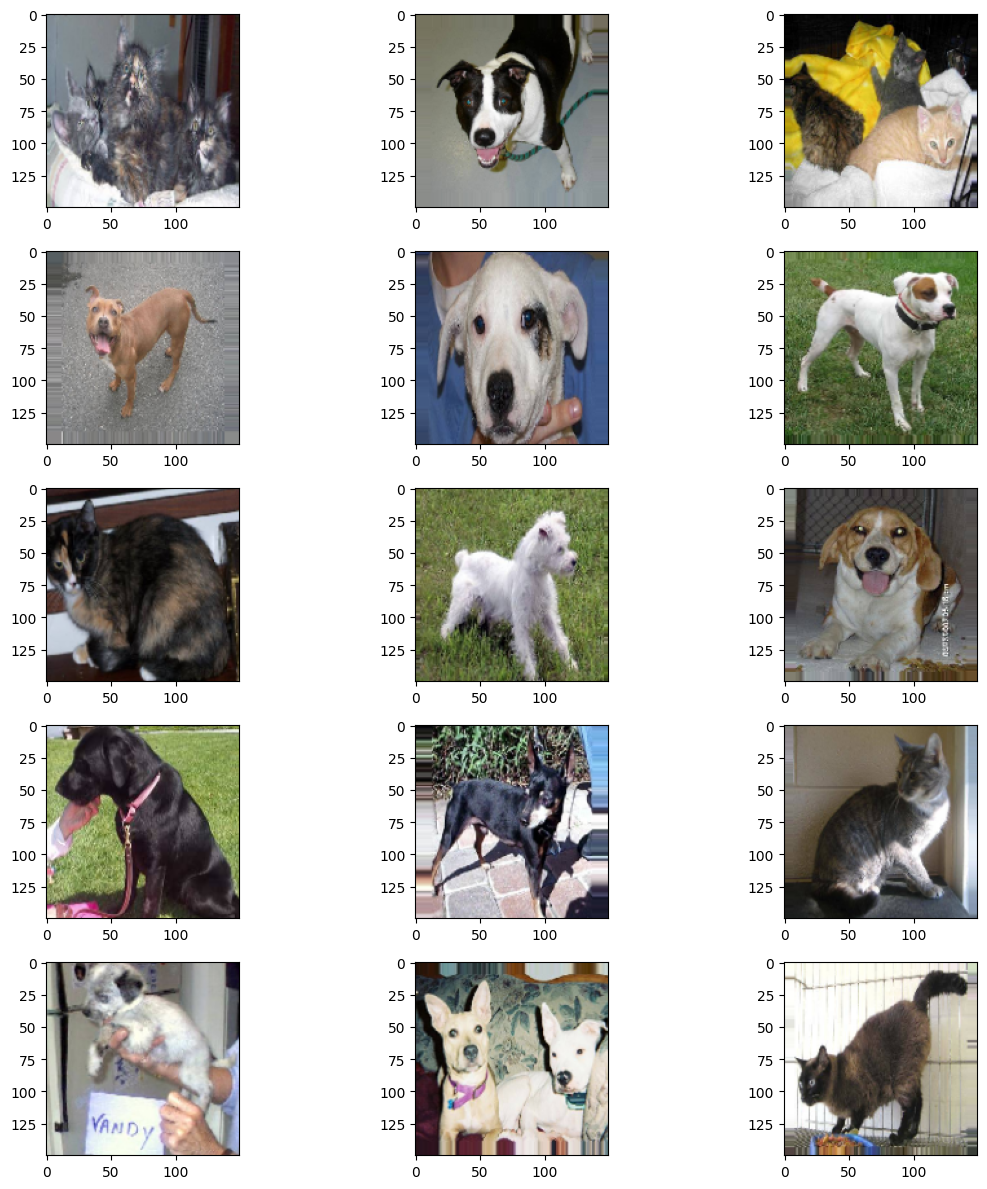

In [ ]:
plt.figure(figsize=(12,12))
for i in range(0,15):
  plt.subplot(5,3,i+1)
  for X_batch,Y_batch in train_generator:
    image=X_batch[0]
    plt.imshow(image)
    break
plt.tight_layout()
plt.show()

In [ ]:
model=Sequential()
model.add(Conv2D(64,(3,3),input_shape=input_shape))#3x3 filter for data
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))#2x2 pooling to reduce data
model.add(Flatten())#convert multi dimensional array to 1 D array
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dense(1))#output layer
model.add(Activation('sigmoid'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 350464)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    22,429,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,431,617 (85.57 MB)

 Trainable params: 22,431,617 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 350464)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    22,429,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,431,617 (85.57 MB)

 Trainable params: 22,431,617 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
training=model.fit(train_generator,steps_per_epoch=nb_train_sample, epochs=epochs, validation_data=validation_generator,validation_steps=nb_validation_samples)


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.5526 - loss: 1.6796 - val_accuracy: 0.6260 - val_loss: 0.6535
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.6070 - loss: 0.6722 - val_accuracy: 0.6135 - val_loss: 0.6501
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6445 - loss: 0.6446 - val_accuracy: 0.6820 - val_loss: 0.6062
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.6710 - loss: 0.6283 - val_accuracy: 0.6750 - val_loss: 0.5907
Epoch 5/20
  1/100 ━━━━━━━━━━━━━━━━━━━━ 2:47 2s/step - accuracy: 0.6500 - loss: 0.5272

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 366ms/step - accuracy: 0.6500 - loss: 0.5272 - val_accuracy: 0.6525 - val_loss: 0.6208
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6595 - loss: 0.6249 - val_accuracy: 0.6955 - val_loss: 0.5765
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.6920 - loss: 0.5985 - val_accuracy: 0.6925 - val_loss: 0.5920
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6745 - loss: 0.6024 - val_accuracy: 0.7055 - val_loss: 0.5641
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6897 - loss: 0.5928 - val_accuracy: 0.7195 - val_loss: 0.5583
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step - accuracy: 0.7000 - loss: 0.5216 - val_accuracy: 0.6415 - val_loss: 0.6350
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6930 - loss: 0.5860 - val_accuracy: 0.7055 - val_loss: 0.5670
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6920 - loss: 0.5808 - val_accuracy

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(training.history.keys())
plt.plot(training.history['accuracy'])
plt.plot(training.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
img_pred=image.load_img("/content/test_set/test_set/dogs/dog.4003.jpg",target_sie=(150,150))
img_pred=image.img_to_array(img_pred)
img_pred=np.expand_dims(img_pred,axis=0)
result=model.predict(img_pred)
print(result)
if result[0][0]==1:
  prediction="Dog"
else:
  prediction="Cat"
print("Prediction : ", prediction)
img=image.imread("/content/test_set/test_set/cats/cat.4002.jpg")
plt.imshow(img)
plt.show()
